# Задание 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

df = pd.read_csv("loan_prediction_dataset.csv")
df.head(15)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


# Задание 2

In [17]:
df.shape
df.info()
df.describe()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002990,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


# Задание 3

In [18]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)

    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    mis_val_table = mis_val_table.rename(
        columns={0: "Missing Values", 1: "% of Total Values"}
    )

    mis_val_table = mis_val_table[
        mis_val_table.iloc[:, 0] != 0
    ].sort_values("% of Total Values", ascending=False).round(2)

    return mis_val_table

missing_values_table(df)

,Missing Values,% of Total Values
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


# Задание 4

## **Матрица пропусков**

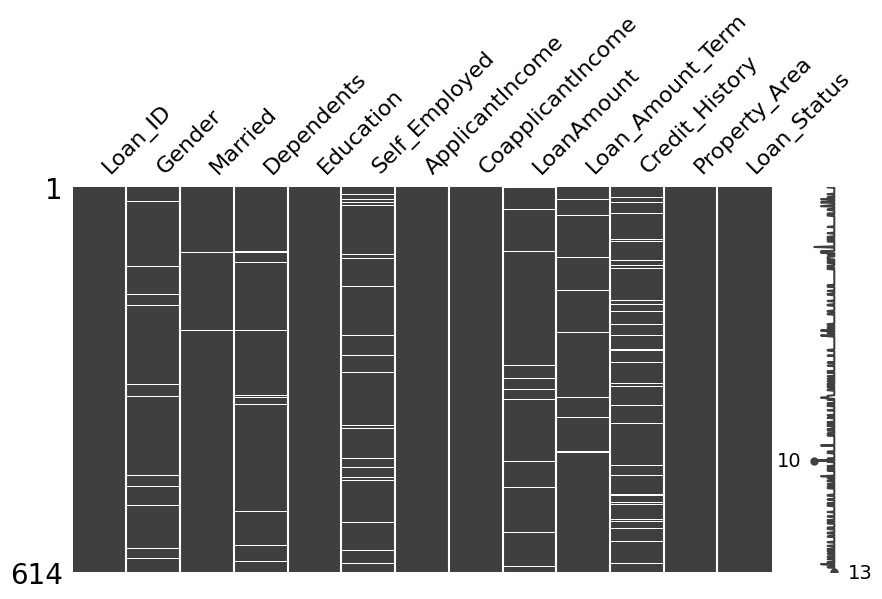

In [5]:
msno.matrix(df, figsize=(10, 5))
plt.show()

## **Тепловая карта пропусков**

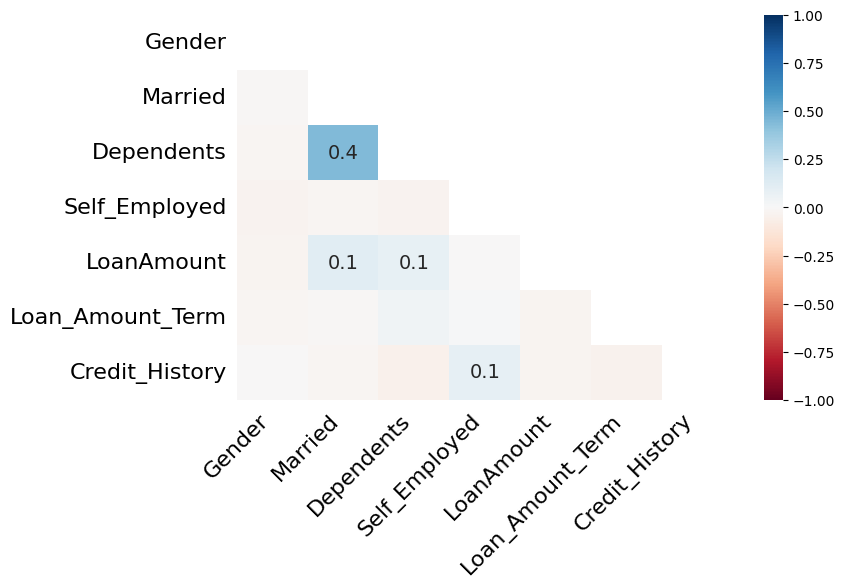

In [6]:
msno.heatmap(df, figsize=(8, 5))
plt.show()

# Задание 5
### 🟦 Интерпретация матрицы пропусков

Матрица пропусков показывает, **в каких ячейках датасета отсутствуют значения**.  
Светлые участки соответствуют пропускам. Можно заметить, что пропуски есть сразу в нескольких столбцах, но они **не собраны в один большой непрерывный фрагмент**. Это говорит о том, что пропущенные значения распределены по датасету **достаточно неравномерно и разрозненно**.

### 🟨 Интерпретация тепловой карты пропусков

Тепловая карта помогает понять, **связаны ли пропуски в одних признаках с пропусками в других**.  
В данном случае заметной сильной зависимости между ними нет. Значит, если в одном столбце значение отсутствует, это **не обязательно связано** с пропуском в другом столбце. Такая ситуация удобна для дальнейшей обработки, потому что каждый признак можно анализировать и заполнять **отдельно**.

# Задание 6

In [7]:
numeric_with_missing = [
    col for col in df.select_dtypes(include=["int64", "float64"]).columns
    if df[col].isnull().sum() > 0
]

categorical_with_missing = [
    col for col in df.select_dtypes(include=["object"]).columns
    if df[col].isnull().sum() > 0
]

print("Numeric features with missing values:")
print(numeric_with_missing)

print("\nCategorical features with missing values:")
print(categorical_with_missing)

Числовые признаки с пропусками:
['LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Категориальные признаки с пропусками:
['Gender', 'Married', 'Dependents', 'Self_Employed']


# Задание 7

In [8]:
df_filled = df.copy()

### **Заполнение категориальных признаков модой**

In [9]:
for col in ["Gender", "Married", "Dependents", "Self_Employed"]:
    df_filled[col] = df_filled[col].fillna(df_filled[col].mode()[0])

### **Заполнение числовых признаков медианой**

In [10]:
for col in ["LoanAmount", "Loan_Amount_Term"]:
    df_filled[col] = df_filled[col].fillna(df_filled[col].median())

### **Заполнение Credit_History модой**

In [11]:
df_filled["Credit_History"] = df_filled["Credit_History"].fillna(
    df_filled["Credit_History"].mode()[0]
)

### **Обоснование выбора метода:**
*Для категориальных признаков используется **мода**, потому что она подставляет наиболее часто встречающееся значение и не создаёт несуществующих категорий.*
*Для LoanAmount и Loan_Amount_Term выбрана **медиана**, так как она устойчивее к выбросам, чем среднее.*
*Для Credit_History используется **мода**, потому что этот признак по смыслу бинарный.*

# Задание 8

In [12]:
df_filled.isnull().sum()
df_filled.isnull().sum().sum()

np.int64(0)

# Задание 9

### **Статистики до заполнения**

In [13]:
cols_with_missing = ["Gender", "Married", "Dependents", "Self_Employed",
                     "LoanAmount", "Loan_Amount_Term", "Credit_History"]

df[cols_with_missing].describe(include="all")

,Gender,Married,Dependents,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History
count,601,611,599,582,592.000000,600.00000,564.000000
unique,2,2,4,2,NaN,NaN,NaN
top,Male,Yes,0,No,NaN,NaN,NaN
freq,489,398,345,500,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,146.412162,342.00000,0.842199
std,NaN,NaN,NaN,NaN,85.587325,65.12041,0.364878
min,NaN,NaN,NaN,NaN,9.000000,12.00000,0.000000
25%,NaN,NaN,NaN,NaN,100.000000,360.00000,1.000000
50%,NaN,NaN,NaN,NaN,128.000000,360.00000,1.000000
75%,NaN,NaN,NaN,NaN,168.000000,360.00000,1.000000


### **Статистики после заполнения**

In [14]:
df_filled[cols_with_missing].describe(include="all")

,Gender,Married,Dependents,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History
count,614,614,614,614,614.000000,614.000000,614.000000
unique,2,2,4,2,NaN,NaN,NaN
top,Male,Yes,0,No,NaN,NaN,NaN
freq,502,401,360,532,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,145.752443,342.410423,0.855049
std,NaN,NaN,NaN,NaN,84.107233,64.428629,0.352339
min,NaN,NaN,NaN,NaN,9.000000,12.000000,0.000000
25%,NaN,NaN,NaN,NaN,100.250000,360.000000,1.000000
50%,NaN,NaN,NaN,NaN,128.000000,360.000000,1.000000
75%,NaN,NaN,NaN,NaN,164.750000,360.000000,1.000000


### **Сравнение числовых признаков до и после заполнения**

In [15]:
numeric_compare = pd.DataFrame({
    "count_before": df[["LoanAmount", "Loan_Amount_Term", "Credit_History"]].count(),
    "count_after": df_filled[["LoanAmount", "Loan_Amount_Term", "Credit_History"]].count(),
    "mean_before": df[["LoanAmount", "Loan_Amount_Term", "Credit_History"]].mean(),
    "mean_after": df_filled[["LoanAmount", "Loan_Amount_Term", "Credit_History"]].mean(),
    "median_before": df[["LoanAmount", "Loan_Amount_Term", "Credit_History"]].median(),
    "median_after": df_filled[["LoanAmount", "Loan_Amount_Term", "Credit_History"]].median(),
}).round(2)

numeric_compare

,count_before,count_after,mean_before,mean_after,median_before,median_after
LoanAmount,592,614,146.41,145.75,128.0,128.0
Loan_Amount_Term,600,614,342.00,342.41,360.0,360.0
Credit_History,564,614,0.84,0.86,1.0,1.0


### **Комментарий**

После обработки пропусков признаки `LoanAmount`, `Loan_Amount_Term` и `Credit_History` стали заполнены полностью.  
Среднее значение и медиана изменились совсем немного, поэтому можно считать, что заполнение **не внесло серьёзных искажений** в данные.  

В категориальных признаках чаще стали встречаться самые популярные значения, потому что именно ими заменялись пропуски.